# HSLS:09 Dropout Prediction — Modelling (Traditional Dropouts Only)

This notebook replicates the full modelling pipeline from notebook 06 but with a
modified target variable. Alternative completers (students who obtained a GED or
equivalent credential by F2) have been recoded from 1 to 0, leaving only traditional
dropouts as the positive class. The same train/test split indices are used for direct
comparison with the original models.

Target variable: X4EVERDROP_TRAD
- 0: Never dropped out OR obtained GED/equivalent by F2 (n=14,118, 89.3%)
- 1: Traditional dropout with no credential (n=1,700, 10.7%)

In [7]:
%run 05_functions_for_modelling.ipynb

In [8]:
import joblib

In [9]:
df = pd.read_csv('hsls_clean_trad.csv')

with open('train_test_split.json') as f:
    split = json.load(f)

with open('feature_tiers.json') as f:
    feature_tiers = json.load(f)

train_idx = split['train']
test_idx  = split['test']

Train dropout rate: 0.1089
Test dropout rate:  0.1018
Train n: 12654, dropouts: 1378
Test n:  3164,  dropouts: 322


In [ ]:
# Check stratification on new target variable
y_train = df.loc[train_idx, 'X4EVERDROP_TRAD']
y_test  = df.loc[test_idx,  'X4EVERDROP_TRAD']

print(f"Train dropout rate: {y_train.mean():.4f}")
print(f"Test dropout rate:  {y_test.mean():.4f}")
print(f"Train n: {len(y_train)}, dropouts: {y_train.sum()}")
print(f"Test n:  {len(y_test)},  dropouts: {y_test.sum()}")

# Tier 1 — Coarse Search

In [10]:
tier1_search_trad, X_train_tier1_trad, y_train_tier1_trad, X_test_tier1_trad, y_test_tier1_trad = fit_models(
    features=feature_tiers['tier1'], df=df, train_idx=train_idx, test_idx=test_idx, target='X4EVERDROP_TRAD')

print("Best params:", tier1_search_trad.best_params_)
print("Best CV F1:", round(tier1_search_trad.best_score_, 4))

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best params: {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.01, 'colsample_bytree': 0.9}
Best CV F1: 0.4127


# Tier 1 — Fine Search

In [11]:
fine_grid_tier1_trad = define_fine_grid(tier1_search_trad.cv_results_)
tier1_fine_search_trad = fit_fine_search(fine_grid_tier1_trad, X_train_tier1_trad, y_train_tier1_trad)

Score range: 0.3417 — 0.4127
Threshold: 0.3985 (34 combinations above threshold)

    mean_test_score  std_test_score  param_n_estimators  param_max_depth  param_learning_rate  param_subsample  param_colsample_bytree
88         0.412689        0.016697                 300                7                0.010              0.7                     0.9
62         0.412491        0.012935                 300               10                0.010              0.8                     0.6
4          0.410960        0.016187                 750                7                0.005              0.6                     0.7
75         0.410315        0.015306                1000                6                0.005              0.6                     1.0
84         0.409089        0.014584                1000                6                0.005              0.9                     1.0
8          0.408161        0.016170                1000                7                0.005              1

# Tier 2 — Coarse Search

In [12]:
tier2_search_trad, X_train_tier2_trad, y_train_tier2_trad, X_test_tier2_trad, y_test_tier2_trad = fit_models(
    features=feature_tiers['tier2'], df=df, train_idx=train_idx, test_idx=test_idx, target='X4EVERDROP_TRAD')

print("Best params:", tier2_search_trad.best_params_)
print("Best CV F1:", round(tier2_search_trad.best_score_, 4))

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best params: {'subsample': 0.6, 'n_estimators': 500, 'max_depth': 10, 'learning_rate': 0.01, 'colsample_bytree': 0.5}
Best CV F1: 0.4243


# Tier 2 — Fine Search

In [13]:
fine_grid_tier2_trad = define_fine_grid(tier2_search_trad.cv_results_)
tier2_fine_search_trad = fit_fine_search(fine_grid_tier2_trad, X_train_tier2_trad, y_train_tier2_trad)

Score range: 0.3548 — 0.4243
Threshold: 0.4104 (16 combinations above threshold)

    mean_test_score  std_test_score  param_n_estimators  param_max_depth  param_learning_rate  param_subsample  param_colsample_bytree
60         0.424280        0.025344                 500               10                0.010              0.6                     0.5
88         0.421980        0.016430                 300                7                0.010              0.7                     0.9
56         0.421456        0.008768                 200               10                0.005              0.9                     0.9
62         0.421189        0.029336                 300               10                0.010              0.8                     0.6
4          0.419549        0.015173                 750                7                0.005              0.6                     0.7
75         0.419218        0.007476                1000                6                0.005              0

# Tier 3 — Coarse Search

In [14]:
tier3_search_trad, X_train_tier3_trad, y_train_tier3_trad, X_test_tier3_trad, y_test_tier3_trad = fit_models(
    features=feature_tiers['tier3'], df=df, train_idx=train_idx, test_idx=test_idx, target='X4EVERDROP_TRAD')

print("Best params:", tier3_search_trad.best_params_)
print("Best CV F1:", round(tier3_search_trad.best_score_, 4))

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best params: {'subsample': 0.6, 'n_estimators': 750, 'max_depth': 7, 'learning_rate': 0.005, 'colsample_bytree': 0.7}
Best CV F1: 0.4452


# Tier 3 — Fine Search

In [15]:
fine_grid_tier3_trad = define_fine_grid(tier3_search_trad.cv_results_)
tier3_fine_search_trad = fit_fine_search(fine_grid_tier3_trad, X_train_tier3_trad, y_train_tier3_trad)

Score range: 0.3435 — 0.4452
Threshold: 0.4248 (19 combinations above threshold)

    mean_test_score  std_test_score  param_n_estimators  param_max_depth  param_learning_rate  param_subsample  param_colsample_bytree
4          0.445159        0.007797                 750                7                0.005              0.6                     0.7
84         0.440325        0.006670                1000                6                0.005              0.9                     1.0
88         0.440009        0.012060                 300                7                0.010              0.7                     0.9
20         0.439342        0.006404                 500                6                0.010              0.9                     0.7
1          0.437293        0.003132                 300                7                0.005              0.7                     0.7
75         0.436619        0.003137                1000                6                0.005              0

# Tier 4 — Coarse Search

In [16]:
tier4_search_trad, X_train_tier4_trad, y_train_tier4_trad, X_test_tier4_trad, y_test_tier4_trad = fit_models(
    features=feature_tiers['tier4'], df=df, train_idx=train_idx, test_idx=test_idx, target='X4EVERDROP_TRAD')

print("Best params:", tier4_search_trad.best_params_)
print("Best CV F1:", round(tier4_search_trad.best_score_, 4))

Fitting 5 folds for each of 100 candidates, totalling 500 fits


/opt/anaconda3/envs/hsls_env/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best params: {'subsample': 0.6, 'n_estimators': 750, 'max_depth': 7, 'learning_rate': 0.005, 'colsample_bytree': 0.7}
Best CV F1: 0.4549


# Tier 4 — Fine Search

In [17]:
fine_grid_tier4_trad = define_fine_grid(tier4_search_trad.cv_results_)
tier4_fine_search_trad = fit_fine_search(fine_grid_tier4_trad, X_train_tier4_trad, y_train_tier4_trad)

Score range: 0.3530 — 0.4549
Threshold: 0.4345 (23 combinations above threshold)

    mean_test_score  std_test_score  param_n_estimators  param_max_depth  param_learning_rate  param_subsample  param_colsample_bytree
4          0.454872        0.006276                 750                7                0.005              0.6                     0.7
75         0.448806        0.011344                1000                6                0.005              0.6                     1.0
84         0.448572        0.008977                1000                6                0.005              0.9                     1.0
20         0.447912        0.005244                 500                6                0.010              0.9                     0.7
57         0.447076        0.009508                 750                6                0.005              0.6                     0.7
89         0.446383        0.013630                 100                8                0.050              0

/opt/anaconda3/envs/hsls_env/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


      mean_test_score  std_test_score  param_colsample_bytree  param_learning_rate  param_max_depth  param_n_estimators  param_subsample
1070         0.465375        0.017424                     0.8                0.010                6                 750              0.6
771          0.463224        0.006105                     0.7                0.010                6                 750              0.7
696          0.460782        0.013717                     0.7                0.005                7                1000              0.7
471          0.459894        0.011612                     0.6                0.010                6                 750              0.7
1596         0.459537        0.008674                     1.0                0.005                7                1000              0.7
172          0.459491        0.009273                     0.5                0.010                6                 750              0.8
485          0.459455        0.009323    

# Save Models and Data

In [ ]:
joblib.dump(tier1_fine_search_trad, 'tier1_fine_search_trad.pkl')
joblib.dump(tier2_fine_search_trad, 'tier2_fine_search_trad.pkl')
joblib.dump(tier3_fine_search_trad, 'tier3_fine_search_trad.pkl')
joblib.dump(tier4_fine_search_trad, 'tier4_fine_search_trad.pkl')

joblib.dump((X_train_tier1_trad, y_train_tier1_trad, X_test_tier1_trad, y_test_tier1_trad), 'data_tier1_trad.pkl')
joblib.dump((X_train_tier2_trad, y_train_tier2_trad, X_test_tier2_trad, y_test_tier2_trad), 'data_tier2_trad.pkl')
joblib.dump((X_train_tier3_trad, y_train_tier3_trad, X_test_tier3_trad, y_test_tier3_trad), 'data_tier3_trad.pkl')
joblib.dump((X_train_tier4_trad, y_train_tier4_trad, X_test_tier4_trad, y_test_tier4_trad), 'data_tier4_trad.pkl')

print("All models and data saved.")

# Evaluation of all models

In [18]:
evaluate_model(tier1_fine_search_trad, X_train_tier1_trad, y_train_tier1_trad, X_test_tier1_trad, y_test_tier1_trad, tier=1)
evaluate_model(tier2_fine_search_trad, X_train_tier2_trad, y_train_tier2_trad, X_test_tier2_trad, y_test_tier2_trad, tier=2)
evaluate_model(tier3_fine_search_trad, X_train_tier3_trad, y_train_tier3_trad, X_test_tier3_trad, y_test_tier3_trad, tier=3)
evaluate_model(tier4_fine_search_trad, X_train_tier4_trad, y_train_tier4_trad, X_test_tier4_trad, y_test_tier4_trad, tier=4)

Tier 1 — Training Set Evaluation
Accuracy:  0.8863
ROC-AUC:   0.9624

              precision    recall  f1-score   support

           0       0.99      0.88      0.93     11276
           1       0.49      0.90      0.63      1378

    accuracy                           0.89     12654
   macro avg       0.74      0.89      0.78     12654
weighted avg       0.93      0.89      0.90     12654

Tier 1 — Test Set Evaluation
Accuracy:  0.8259
ROC-AUC:   0.8260

              precision    recall  f1-score   support

           0       0.95      0.85      0.90      2842
           1       0.32      0.61      0.42       322

    accuracy                           0.83      3164
   macro avg       0.63      0.73      0.66      3164
weighted avg       0.89      0.83      0.85      3164

Tier 2 — Training Set Evaluation
Accuracy:  0.9580
ROC-AUC:   0.9979

              precision    recall  f1-score   support

           0       1.00      0.95      0.98     11276
           1       0.72      0.

# Results Summary

In [19]:
from sklearn.metrics import f1_score, recall_score, precision_score, roc_auc_score, accuracy_score

summary_trad = []

for tier, fine_search, X_train, y_train, X_test, y_test in [
    (1, tier1_fine_search_trad, X_train_tier1_trad, y_train_tier1_trad, X_test_tier1_trad, y_test_tier1_trad),
    (2, tier2_fine_search_trad, X_train_tier2_trad, y_train_tier2_trad, X_test_tier2_trad, y_test_tier2_trad),
    (3, tier3_fine_search_trad, X_train_tier3_trad, y_train_tier3_trad, X_test_tier3_trad, y_test_tier3_trad),
    (4, tier4_fine_search_trad, X_train_tier4_trad, y_train_tier4_trad, X_test_tier4_trad, y_test_tier4_trad),
]:
    model = fine_search.best_estimator_
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    summary_trad.append({
        'Tier': tier,
        'Features': X_test.shape[1],
        'CV F1': round(fine_search.best_score_, 4),
        'Test Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'Test Precision': round(precision_score(y_test, y_pred), 4),
        'Test Recall': round(recall_score(y_test, y_pred), 4),
        'Test F1': round(f1_score(y_test, y_pred), 4),
        'Test ROC-AUC': round(roc_auc_score(y_test, y_prob), 4),
    })

summary_trad_df = pd.DataFrame(summary_trad)
print(summary_trad_df.to_string(index=False))

 Tier  Features  CV F1  Test Accuracy  Test Precision  Test Recall  Test F1  Test ROC-AUC
    1       130 0.4181         0.8259          0.3168       0.6149   0.4182        0.8260
    2       192 0.4353         0.8692          0.3905       0.5093   0.4420        0.8238
    3       436 0.4502         0.8594          0.3721       0.5559   0.4458        0.8346
    4       833 0.4654         0.8638          0.3895       0.5963   0.4712        0.8422


# Feature Importance

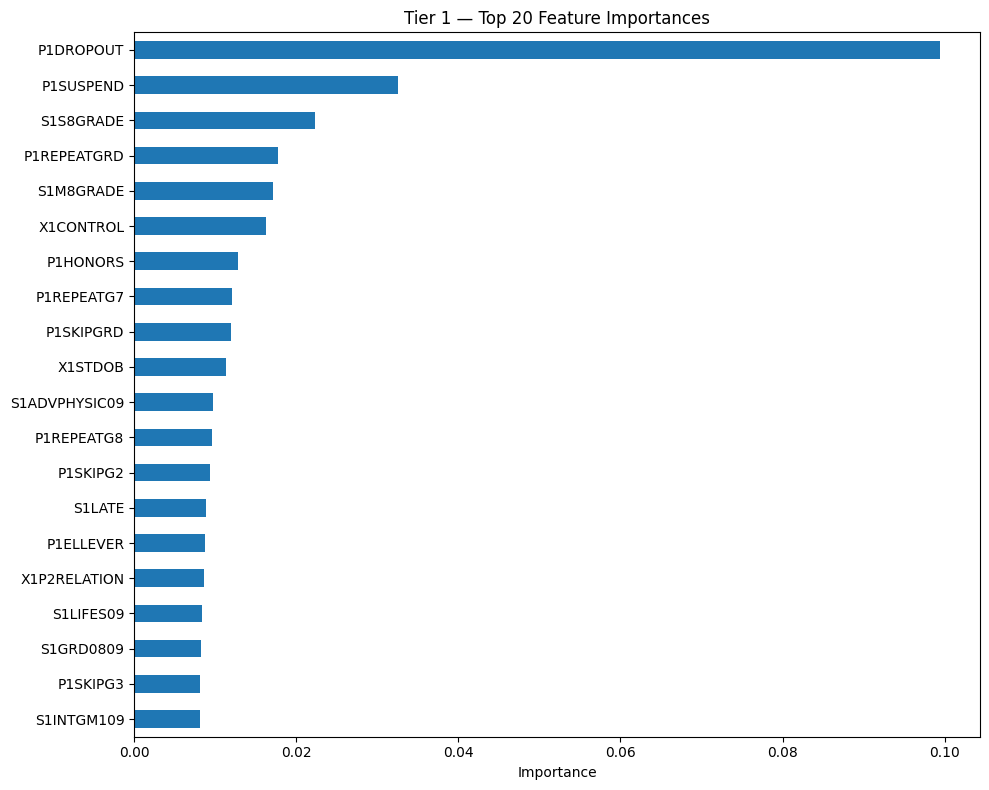

Tier 1 — Bottom 20 features:
S1SFALL09      0.005299
X1SEX          0.005287
P1USGRADE      0.005264
X1RACE         0.005116
P1DD           0.005093
P1USBORN9      0.005074
P1REPEATG5     0.004989
X1WHITE        0.004962
P1REPEATG1     0.004814
A1G9OTHER      0.004577
S1ANGEOM09     0.004500
P1REPEATGK     0.004301
P1REPEATG3     0.004301
S1MFALL09      0.004268
A1G9TCHREF     0.004059
S1REVM09       0.003595
S1OTHBIOS09    0.003540
P1AUTISM       0.003538
P1REPEATG9     0.002994
P1REPEATG4     0.002250



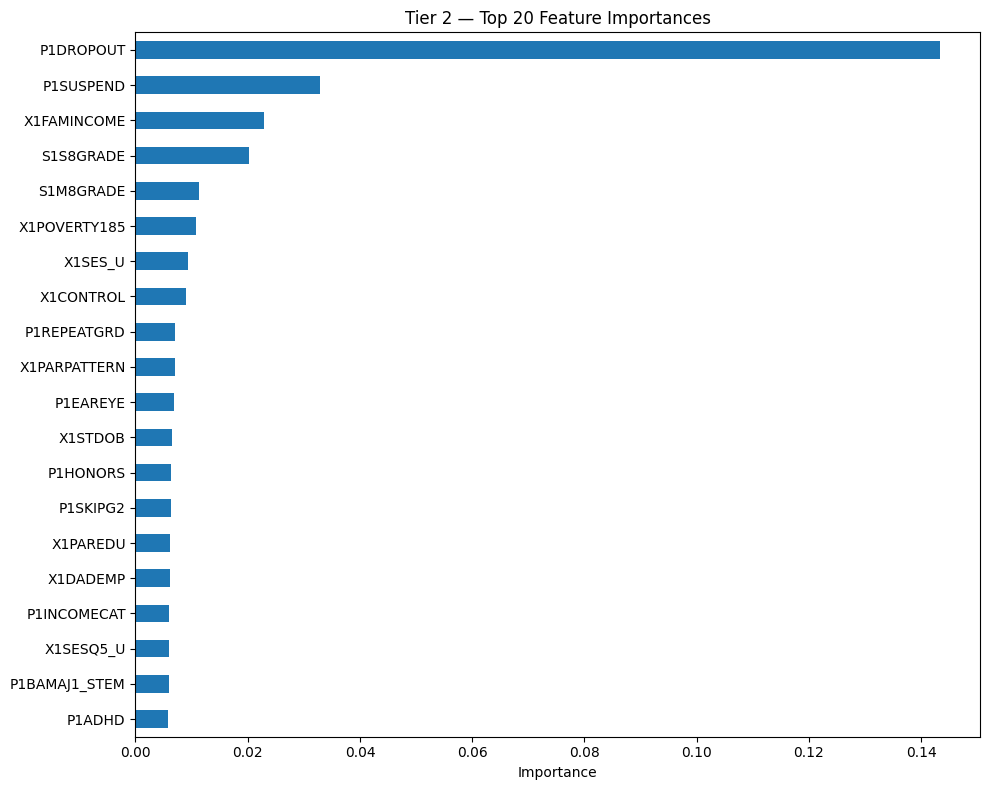

Tier 2 — Bottom 20 features:
P1REPEATGK         0.002955
X1WHITE            0.002938
X1SEX              0.002937
X1PAR1OCC_STEM1    0.002884
P1USGRADE          0.002775
X1RACE             0.002700
X1PAR2OCC_STEM1    0.002692
X1PAR1EDU          0.002689
A1G9TCHREF         0.002681
S1STATSM09         0.002594
S1REVM09           0.002456
S1ANGEOM09         0.002198
P1JOBEVER1         0.002144
S1OTHENVS09        0.001879
P1SKIPG8           0.001851
P1REPEATG4         0.001754
P1REPEATG9         0.001647
P1AUTISM           0.001631
S1ADVM09           0.000000
S1ADVPHYSIC09      0.000000



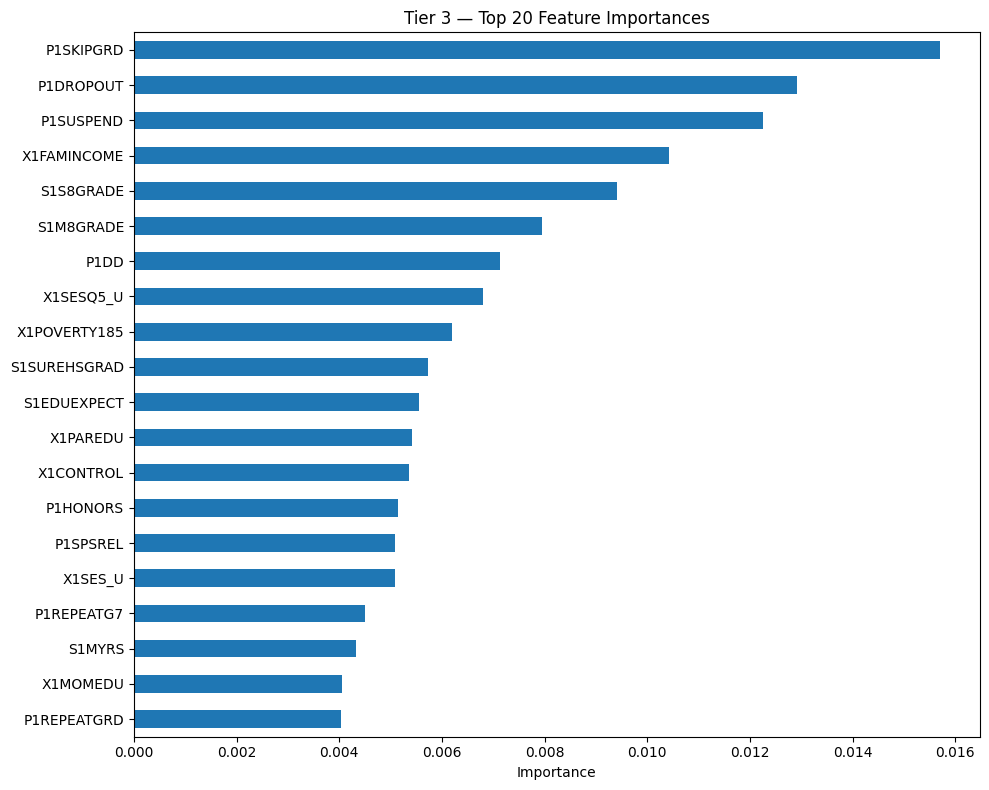

Tier 3 — Bottom 20 features:
S1SFALL09        0.001055
C1POORGRADES     0.001047
S1MTUTOR         0.001026
X1SEX            0.001017
X1PAR1EDU        0.000978
P1REPEATG5       0.000968
A1G9TCHREF       0.000901
S1MCLUB          0.000874
X1HISPANIC       0.000867
P1JOBEVER1       0.000839
S1ANGEOM09       0.000803
S1OTHENVS09      0.000639
S1REVM09         0.000609
P1REPEATG9       0.000569
S1FEEPRV         0.000562
S1GENS09         0.000562
P1REPEATG4       0.000425
S1ADVBIOS09      0.000372
P1JOBEVER2       0.000000
S1ADVPHYSIC09    0.000000



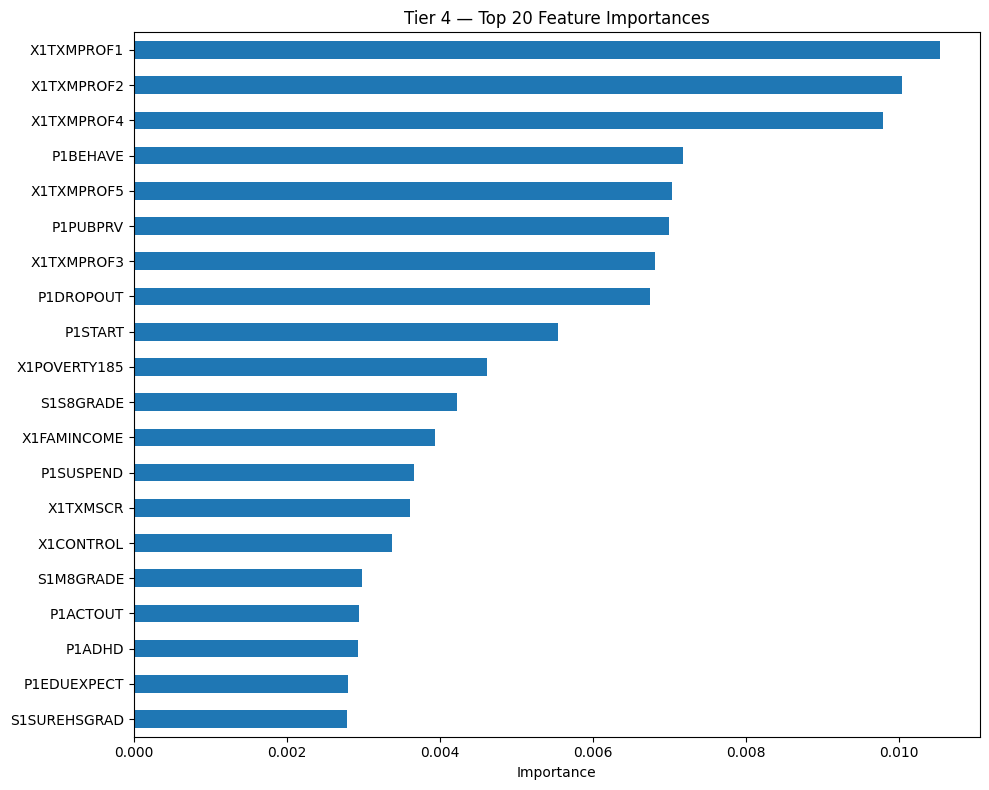

Tier 4 — Bottom 20 features:
A1G9TCHREF       0.000407
S1REVM09         0.000398
S1GENS09         0.000391
A1G9GRADES       0.000386
X1PAR1EDU        0.000378
P1ADHDMED        0.000376
X1DUALLANG       0.000352
A1NOTIFY         0.000332
S1MFALL09        0.000306
P1REPEATG1       0.000299
P1SKIPG8         0.000290
P1REPEATG9       0.000229
P1REPEATG4       0.000147
C1HSTOWORKNO     0.000098
C1POSTSECREQ     0.000077
X1TXMQUINT       0.000000
S1ADVPHYSIC09    0.000000
S1ANGEOM09       0.000000
S1OTHPHYS09      0.000000
S1OTHENVS09      0.000000



In [20]:
show_feature_importance(tier1_fine_search_trad, X_train_tier1_trad, tier=1)
show_feature_importance(tier2_fine_search_trad, X_train_tier2_trad, tier=2)
show_feature_importance(tier3_fine_search_trad, X_train_tier3_trad, tier=3)
show_feature_importance(tier4_fine_search_trad, X_train_tier4_trad, tier=4)

# Feature Importance Comparison Across Tiers

In [21]:
compare_feature_importance(
    [tier1_fine_search_trad, tier2_fine_search_trad, tier3_fine_search_trad, tier4_fine_search_trad],
    [X_train_tier1_trad, X_train_tier2_trad, X_train_tier3_trad, X_train_tier4_trad])

Feature overlap across tiers (top 20 each):
Feature                     T1   T2   T3   T4  Tiers
--------------------------------------------------
S1S8GRADE                    3    4    5   11      4
S1M8GRADE                    5    5    6   16      4
X1CONTROL                    6    8   13   15      4
P1SUSPEND                    2    2    3   13      4
P1DROPOUT                    1    1    2    8      4
X1FAMINCOME                  -    3    4   12      3
P1HONORS                     7   13   14    -      3
X1POVERTY185                 -    6    9   10      3
P1REPEATGRD                  4    9   20    -      3
P1SKIPG2                    13   14    -    -      2
X1SES_U                      -    7   16    -      2
X1STDOB                     10   12    -    -      2
P1REPEATG7                   8    -   17    -      2
X1SESQ5_U                    -   18    8    -      2
P1ADHD                       -   20    -   18      2
P1SKIPGRD                    9    -    1    -      2
S1SU

# SHAP Analysis

In [ ]:
plot_shap(tier1_fine_search_trad, X_train_tier1_trad, tier=1)
plot_shap(tier2_fine_search_trad, X_train_tier2_trad, tier=2)
plot_shap(tier3_fine_search_trad, X_train_tier3_trad, tier=3)
plot_shap(tier4_fine_search_trad, X_train_tier4_trad, tier=4)

# Precision-Recall Curves

In [ ]:
from sklearn.metrics import precision_recall_curve

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (tier, fine_search, X_test, y_test) in enumerate([
    (1, tier1_fine_search_trad, X_test_tier1_trad, y_test_tier1_trad),
    (2, tier2_fine_search_trad, X_test_tier2_trad, y_test_tier2_trad),
    (3, tier3_fine_search_trad, X_test_tier3_trad, y_test_tier3_trad),
    (4, tier4_fine_search_trad, X_test_tier4_trad, y_test_tier4_trad),
]):
    model = fine_search.best_estimator_
    y_prob = model.predict_proba(X_test)[:, 1]
    precisions, recalls, _ = precision_recall_curve(y_test, y_prob)
    axes[i].plot(recalls, precisions)
    axes[i].set_title(f'Tier {tier}')
    axes[i].set_xlabel('Recall')
    axes[i].set_ylabel('Precision')
    axes[i].grid(True)

plt.suptitle('Precision-Recall Curves by Tier — Traditional Dropouts Only')
plt.tight_layout()
plt.show()